In [1]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
import jieba
import numpy as np
from sklearn.impute import SimpleImputer

/Users/qingjiabu/Library/Python/3.12/lib/python/site-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# 1. 数据中含有字符串的时候，如何做特征提取

In [2]:
def dict_vec():
    """
    字典数据提取
    :return: 
    """
    # DictVectorizer：sklearn的类，字典向量化工具
    sample_dict = DictVectorizer(sparse=True)
    # DictVectorizer(sparse=False) -> 调用类，创建一个实例对象
    user_dict = DictVectorizer(sparse=False)
    """
    fit_transform = fit(学习、统计规则，收集所有特征名，确定输出矩阵有多少列) + transform（用fit学到的规则，把输入数据转换成数值矩阵）
    fit核心作用：
        1：遍历全部样本的每一个key（字典键）
        2: 如果value是字符串（分类）：生成 key=取值 作为特征名，如city=北京
        3: 如果value是数字（连续数值）：直接拿key当特征名，如age
        4: 全部收集、去重、排好顺序，保存到对象内部 feature_names_
        特征总数量 = len(dict_vectorizer.feature_names_)
    fit结束后对象里存两份核心信息：
        1: feature_names_： 特征名字列表['city=上海' 'city=北京' 'city=深圳' 'temperature']
        2: _vocabulary：字典{"city=上海": 0, "city=北京": 1, "city=深圳": 2, "temperature": 3}
            key：特征名     value：对应矩阵的索引
        fit完成：只是建好一张 [特征->列号] 对照表，没有生成任何数值矩阵
    transform作用：
        transform拿着fit阶段生成好的_vocabulary对照表，遍历原始样本，把每一条字典翻译成数字矩阵（sparse的不同决定了实例化方法返回的数据的不同）
        
    模拟DictVectorizer.fit的简易伪代码
    def my_fit(dict_list):
        feature_set = set()                                     # 定义为集合避免特征名重复
        for sample in dict_list:                                # 遍历每一个字典
            for k, v in sample.items():                         # 遍历每一个键值对
                if isinstance(v, str):                          # 如果是字符串则 k=v
                    feature_name = f'{k}={v}'
                else:
                    feature_name = k                            # 否则直接 k
                feature_set.add(feature_name)
        feature_names = sorted(feature_set)
        return feature_names
    """
    # 调用实例化方法fit_transform，返回类似与三元组的稀疏矩阵
    sample_data = sample_dict.fit_transform([{'city': '北京', 'temperature': 100}, {'city': '上海', 'temperature': 60}, {'city': '深圳', 'temperature': 30}])
    # 返回普通numpy二维数组，方便打印查看结果
    user_data = user_dict.fit_transform([{'city': '北京', 'temperature': 100}, {'city': '上海', 'temperature': 60}, {'city': '深圳', 'temperature': 30}])
    
    # 类似于数据结构中三元组，只记录矩阵中非零数值
    print(sample_data)
    print(type(sample_data))                            # <class 'scipy.sparse._csr.csr_matrix'>
    print('-' * 50)
    
    print(user_data)
    print(type(user_data))                              # <class 'numpy.ndarray'>
    print('--' * 50)
    
    # 调用实例对象user_dict的另一个方法返回特征名字列表
    # 这里打印出来的就是实例属性 feature_names_ 的值
    print(user_dict.get_feature_names_out())            # ['city=上海' 'city=北京' 'city=深圳' 'temperature']
    print('-' * 50)
    # 通过user_dict内部保存的实例属性 以及 user_data这个ndarray数组 返回原始数据
    print(user_dict.inverse_transform(user_data))
    
dict_vec()

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6 stored elements and shape (3, 4)>
  Coords	Values
  (0, 1)	1.0
  (0, 3)	100.0
  (1, 0)	1.0
  (1, 3)	60.0
  (2, 2)	1.0
  (2, 3)	30.0
<class 'scipy.sparse._csr.csr_matrix'>
--------------------------------------------------
[[  0.   1.   0. 100.]
 [  1.   0.   0.  60.]
 [  0.   0.   1.  30.]]
<class 'numpy.ndarray'>
----------------------------------------------------------------------------------------------------
['city=上海' 'city=北京' 'city=深圳' 'temperature']
--------------------------------------------------
[{'city=北京': np.float64(1.0), 'temperature': np.float64(100.0)}, {'city=上海': np.float64(1.0), 'temperature': np.float64(60.0)}, {'city=深圳': np.float64(1.0), 'temperature': np.float64(30.0)}]


# 2. 一段英文文本如何变成数值类型

In [1]:
def count_vec():
    # 创建词频计数器对象，把文本转成词袋（Bag-of-Words）矩阵
    # min_df（minimum document frequency）：最小文档出现次数
    vector = CountVectorizer(min_df=2)
    """
    关键点：CountVectorizer默认做英文分词，单字母会被过滤掉
    默认正则分词规则：
        token_pattern=r"(?u)\b\w\w+\b"
        \w\w+：匹配至少2个及以上字符的单词
    单字符单词i（只有1个字母）直接在分词阶段就被丢弃，根本进不到min_df筛选那一步
    """
    res = vector.fit_transform(["life is short, i like python life", "life is too long, i dislike python", "life is too short"])
    print(vector.get_feature_names_out())
    print('--' * 50)
    
    print(res)
    print(type(res))                            # <class 'scipy.sparse._csr.csr_matrix'>
    print('--' * 50)
    
    # 将稀疏矩阵转换为ndarray数组
    print(res.toarray())
    print(type(res.toarray()))                  # <class 'numpy.ndarray'>
    print('--' * 50)
    
    print(vector.inverse_transform(res))
    
count_vec()

NameError: name 'CountVectorizer' is not defined

# 一段汉字文本如何数值化，对于汉字不能用空格来分割

In [4]:
def count_vec():
    """
    对文本进行特征值化，单个汉字单个字母不统计，因为单个汉字字母没有意义
    :return: 
    """
    # 词频计数器
    cv = CountVectorizer()
    # 不同jieba时通过空格和逗号区分词语
    data = cv.fit_transform(["人生苦短， 我 喜欢 python python", "人生漫长，不用 python"])
    
    print(data)
    print('--' * 50)
    print(cv.get_feature_names_out())
    print('--' * 50)
    print(data.toarray())
    
    return None

count_vec()

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 6 stored elements and shape (2, 5)>
  Coords	Values
  (0, 3)	1
  (0, 4)	1
  (0, 0)	2
  (1, 0)	1
  (1, 2)	1
  (1, 1)	1
----------------------------------------------------------------------------------------------------
['python' '不用' '人生漫长' '人生苦短' '喜欢']
----------------------------------------------------------------------------------------------------
[[2 0 0 1 1]
 [1 1 1 0 0]]


# 掌握如何对中文进行分词

In [5]:
def cut_word():
    """
    通过jieba对中文进行分词
    :return: 
    """
    con1 = jieba.cut("今天很残酷，明天更残酷，后天很美好，但绝大部分是死在明天晚上，所以每个人不要放弃今天。")
    con2 = jieba.cut("我们看到的从很远星系来的光是在几百万年之前发出的，这样当我们看到宇宙时，我们是在看它的过去。")
    con3 = jieba.cut("如果只用一种方式了解某样食物，你就不会真正了解它。了解事物真正含义的秘密取决于如何将其与我们所了解的事物相联系。")   
    print(con1)                                 # <generator object Tokenizer.cut at 0x16b760880>
    print(type(con1))                           # <class 'generator'>
    print('--' * 50)
    
    content1 = list(con1)
    content2 = list(con2)
    content3 = list(con3)
    print(content1)
    print('-' * 50)
    print(content2)
    print('-' * 50)
    print(content3)
    
    print('--' * 50)
    c1 = ' '.join(content1)
    c2 = ' '.join(content2)
    c3 = ' '.join(content3)
    
    # 以元组形式返回数据
    return c1, c2, c3

tuple_three = cut_word()
print(tuple_three)

Building prefix dict from the default dictionary ...


<generator object Tokenizer.cut at 0x1769b71c0>
<class 'generator'>
----------------------------------------------------------------------------------------------------


Dumping model to file cache /var/folders/pb/p_cly9gj3xv6l7083h32ln_80000gn/T/jieba.cache
Loading model cost 0.376 seconds.
Prefix dict has been built successfully.


['今天', '很', '残酷', '，', '明天', '更', '残酷', '，', '后天', '很', '美好', '，', '但', '绝大部分', '是', '死', '在', '明天', '晚上', '，', '所以', '每个', '人', '不要', '放弃', '今天', '。']
--------------------------------------------------
['我们', '看到', '的', '从', '很', '远', '星系', '来', '的', '光是在', '几百万年', '之前', '发出', '的', '，', '这样', '当', '我们', '看到', '宇宙', '时', '，', '我们', '是', '在', '看', '它', '的', '过去', '。']
--------------------------------------------------
['如果', '只用', '一种', '方式', '了解', '某样', '食物', '，', '你', '就', '不会', '真正', '了解', '它', '。', '了解', '事物', '真正', '含义', '的', '秘密', '取决于', '如何', '将', '其', '与', '我们', '所', '了解', '的', '事物', '相', '联系', '。']
----------------------------------------------------------------------------------------------------
('今天 很 残酷 ， 明天 更 残酷 ， 后天 很 美好 ， 但 绝大部分 是 死 在 明天 晚上 ， 所以 每个 人 不要 放弃 今天 。', '我们 看到 的 从 很 远 星系 来 的 光是在 几百万年 之前 发出 的 ， 这样 当 我们 看到 宇宙 时 ， 我们 是 在 看 它 的 过去 。', '如果 只用 一种 方式 了解 某样 食物 ， 你 就 不会 真正 了解 它 。 了解 事物 真正 含义 的 秘密 取决于 如何 将 其 与 我们 所 了解 的 事物 相 联系 。')


In [6]:
def hanzi_vec():
    """
    中文特征值化
    :return: 
    """
    c1, c2, c3 = tuple_three
    print(c1)
    print('-' * 50)
    print(c2)
    print('-' * 50)
    print(c3)
    print('--' * 50)
    
    cv = CountVectorizer()
    data = cv.fit_transform([c1, c2, c3])
    
    print(cv.get_feature_names_out())
    print(data.toarray())
    return None

hanzi_vec()

今天 很 残酷 ， 明天 更 残酷 ， 后天 很 美好 ， 但 绝大部分 是 死 在 明天 晚上 ， 所以 每个 人 不要 放弃 今天 。
--------------------------------------------------
我们 看到 的 从 很 远 星系 来 的 光是在 几百万年 之前 发出 的 ， 这样 当 我们 看到 宇宙 时 ， 我们 是 在 看 它 的 过去 。
--------------------------------------------------
如果 只用 一种 方式 了解 某样 食物 ， 你 就 不会 真正 了解 它 。 了解 事物 真正 含义 的 秘密 取决于 如何 将 其 与 我们 所 了解 的 事物 相 联系 。
----------------------------------------------------------------------------------------------------
['一种' '不会' '不要' '之前' '了解' '事物' '今天' '光是在' '几百万年' '发出' '取决于' '只用' '后天' '含义'
 '如何' '如果' '宇宙' '我们' '所以' '放弃' '方式' '明天' '星系' '晚上' '某样' '残酷' '每个' '看到'
 '真正' '秘密' '绝大部分' '美好' '联系' '过去' '这样' '食物']
[[0 0 1 0 0 0 2 0 0 0 0 0 1 0 0 0 0 0 1 1 0 2 0 1 0 2 1 0 0 0 1 1 0 0 0 0]
 [0 0 0 1 0 0 0 1 1 1 0 0 0 0 0 0 1 3 0 0 0 0 1 0 0 0 0 2 0 0 0 0 0 1 1 0]
 [1 1 0 0 4 2 0 0 0 0 1 1 0 1 1 1 0 1 0 0 1 0 0 0 1 0 0 0 2 1 0 0 1 0 0 1]]


# 1.4 tf-idf（词频-逆文档频率）

In [7]:
def tf_idf_vec():
    c1, c2, c3 = tuple_three
    print(c1, c2, c3)
    print(type([c1, c2, c3]))
    print('--' * 50)
    """
    CountVectorizer：只统计词出现次数；
    TfidfVectorizer：统计TF-IDF权重，不只看出现多少次，还看这个词重不重要
    TF-IDF两层含义：
        TF词频：这个词在当前这篇文档里出现多少次
        IDF逆文档频率：这个词是不是到处都出现
            到处都出现（的、the）-> IDF很小，权重压低
            只少数文档出现（专属关键词）-> IDF大，权重拉高
        最终输出矩阵里每一个数值 = TF * IDF
        
    核心参数：
        smooth_idf=True（默认就是 True，一般不用手写出来）
    作用：
        解决某个词只在测试集出现、训练集完全没见过的情况。
    IDF 原始公式：
        idf(t)=log(n / df(t))
            n：总文档数
            df(t)：包含词 t 的文档数量
    如果一个词训练集里一篇都没有，df(t)=0，分母为 0，计算报错。
        smooth_idf=True：做加 1 平滑
        idf(t)=log((n+1) / (df(t)+1)) +1
        分子分母都 + 1，避免分母等于 0；对所有词的 idf 都轻微修正。
    smooth_idf=True：开启平滑，工程上几乎永远用 True
    smooth_idf=False：关闭平滑，遇到训练集未出现的词会出现计算异常
    """
    tf = TfidfVectorizer(smooth_idf=True)
    data = tf.fit_transform([c1, c2, c3])
    
    print(tf.get_feature_names_out())
    print('--' * 50)
    print(type(data))                           # <class 'scipy.sparse._csr.csr_matrix'>
    print('--' * 50)
    print(data.toarray())
    
    return None

tf_idf_vec()

今天 很 残酷 ， 明天 更 残酷 ， 后天 很 美好 ， 但 绝大部分 是 死 在 明天 晚上 ， 所以 每个 人 不要 放弃 今天 。 我们 看到 的 从 很 远 星系 来 的 光是在 几百万年 之前 发出 的 ， 这样 当 我们 看到 宇宙 时 ， 我们 是 在 看 它 的 过去 。 如果 只用 一种 方式 了解 某样 食物 ， 你 就 不会 真正 了解 它 。 了解 事物 真正 含义 的 秘密 取决于 如何 将 其 与 我们 所 了解 的 事物 相 联系 。
<class 'list'>
----------------------------------------------------------------------------------------------------
['一种' '不会' '不要' '之前' '了解' '事物' '今天' '光是在' '几百万年' '发出' '取决于' '只用' '后天' '含义'
 '如何' '如果' '宇宙' '我们' '所以' '放弃' '方式' '明天' '星系' '晚上' '某样' '残酷' '每个' '看到'
 '真正' '秘密' '绝大部分' '美好' '联系' '过去' '这样' '食物']
----------------------------------------------------------------------------------------------------
<class 'scipy.sparse._csr.csr_matrix'>
----------------------------------------------------------------------------------------------------
[[0.         0.         0.2236068  0.         0.         0.
  0.4472136  0.         0.         0.         0.         0.
  0.2236068  0.         0.         0.         0.         0.
  0.2236068  0.2236068  0.         0.

In [31]:
a = ('我', '和', '你')
print(a)
print(type(a))

('我', '和', '你')
<class 'tuple'>


# 2. 特征处理，不同的特征拉到同一个量纲

In [18]:
def min_max():
    """
    归一化处理
    :return: None
    """
    """
    MinMaxScaler 最小‑最大归一化
        参数 feature_range=(0,1)，默认就是 (0,1)，可以不写
        
    含义：把每一列特征，压缩映射到 [最小值，最大值] 区间，这里就是 0～1。
    
    公式：
        X_scaled = (X - X_min) / (X_max - X_min)
        X_min：该特征在训练集上的最小值
        X_max：该特征在训练集上的最大值
    """
    user = MinMaxScaler(feature_range=(0, 1))
    """ 
    输入原始数据（3 行 4 列，3 个样本，4 个特征）
        样本1：[90, 2, 10, 40]
        样本2：[60, 4, 15, 45]
        样本3：[75, 3, 13, 46]
        
    fit_transform做两件事：
        fit：统计每一列的 min、max
            第 0 列：min=60，max=90
            第 1 列：min=2，max=4
            第 2 列：min=10，max=15
            第 3 列：min=40，max=46
        transform，套用公式：
            X_scaled = (X - X_min) / (X_max - X_min)
    """
    data = user.fit_transform([[90, 2, 10, 40], [60, 4, 15, 45], [75, 3, 13, 46]])
    
    print(data)
    print(type(data))
    
    return None

min_max()

[[1.         0.         0.         0.        ]
 [0.         1.         1.         0.83333333]
 [0.5        0.5        0.6        1.        ]]
<class 'numpy.ndarray'>


In [19]:
def stand():
    """
    标准化缩放，不是标准正态分布，只均值为0，方差为1的分布
    
    StandardScaler不会把数据变成正态分布
    它只做线性变换，强制让变换后数据 均值=0、方差=1，原始数据是什么分布，变换之后还是什么分布，不会把非正态强行变成正态分布
    
    变换公式：
        z = (x - μ) / σ
        x：原始数据；μ：该列原始数据均值；σ：该列原始数据标准差；z：标准化之后的数据
        
    数学简单证明（为什么做完标准化后均值 0，方差 1）
        设经过第一步中心化：x' = x − μ，此时 mean(x') = 0
        
        Var(z) = Var( x' / σ ) = Var(x') / σ²
        σ² 就是原始方差 Var(x')，所以 Var(z) = 1
        
        第一步减均值：把整体数据平移，使均值变为0，方差保持不变
        第二步除以标准差：缩放离散程度，使方差变为1
    :return: 
    """
    std = StandardScaler()
    """
    总体方差（StandardScaler 使用，除以n）
        σ² = 1/n * Σ (x_i − μ)²
        μ：总体均值，n：数据个数，x_i：每个数据点
    
    样本方差（无偏估计，除以 n‑1）
        s² = 1/(n‑1) * Σ (x_i − x̄)²
        x̄：样本均值
        
    StandardScaler 用的是总体方差，除以 n，不是 n‑1
    """
    data = std.fit_transform([[1, -1, 3], [2, 4, 2], [4, 6, -1]])
    
    print(data)
    print('--' * 50)
    # 原始数据每一列的均值（缩放之前原始特征的均值）
    print(std.mean_)
    print('--' * 50)
    # 缩放之前原始特征的方差
    print(std.var_)
    # 样本数
    print(std.n_samples_seen_)
    return None

stand()

[[-1.06904497 -1.35873244  0.98058068]
 [-0.26726124  0.33968311  0.39223227]
 [ 1.33630621  1.01904933 -1.37281295]]
----------------------------------------------------------------------------------------------------
[2.33333333 3.         1.33333333]
----------------------------------------------------------------------------------------------------
[1.55555556 8.66666667 2.88888889]
3.0


In [20]:
std1 = StandardScaler()
# 为了证明上面输出的结果均值为0，方差为1
data1 = std1.fit_transform([[-1.06904497, -1.35873244, 0.98058068], 
                            [-0.26726124, 0.33968311, 0.39223227], 
                            [1.33630621, 1.01904933, -1.37281295]])
print(data1)
print(std1.mean_)
print(std1.var_)

[[-1.06904497 -1.35873244  0.98058068]
 [-0.26726124  0.33968311  0.39223227]
 [ 1.33630621  1.01904933 -1.37281295]]
[0. 0. 0.]
[1.         1.         1.00000001]


In [21]:
# σ² = 1/n * Σ (x_i − μ)²               方差
(np.square(1 - 2.333) + np.square(2 - 2.333) + np.square(4 - 2.333)) / 3

np.float64(1.5555556666666668)

In [22]:
# σ = sqrt( 1/n * Σ (x_i − μ)² )        标准差
# z_i = (x_i - μ) / σ
(1 - 2.333) / np.sqrt(1.55555)

np.float64(-1.068779614944516)

## transform和fit_transform不同是，transform用于测试集，而且不会重新找最小值和最大值，不会重新计算均值方差

# 3. 缺失值处理

In [24]:
def im():
    """
    缺失值处理
    :return: None
    """
    # NaN, nan,缺失值必须是这种形式，如果是？号(或者其他符号)，就要replace换成这种
    # mean：均值填充，该列 非缺失数据的平均值 去填NaN，只对数值特征有效
    im = SimpleImputer(missing_values=np.nan, strategy='mean')
    
    data = im.fit_transform([[1, 2], 
                             [np.nan, 3], 
                             [7, 6],
                             [3, 2]])
    print(data)
    
    return None

im()

[[1.         2.        ]
 [3.66666667 3.        ]
 [7.         6.        ]
 [3.         2.        ]]


# 4. 降维 降维就是特征数变少，降维可以提高模型训练速度（模型参数变少了）

In [28]:
def var():
    """
    特征选择-删除低方差的特征
    :return: None
    """
    var = VarianceThreshold(threshold=0.6)
    """
    逐列看方差：
        第 0 列：[0,0,0]，全部是 0 → 方差 = 0
        第 1 列：[2,1,1] → 方差 ≈ 0.222
        第 2 列：[0,4,1] → 方差 ≈ 2.889
        第 3 列：[3,3,3]，全部是 3 → 方差 = 0
        threshold=0.6：保留方差 >0.6 的列
    只有第 2 列方差 2.889＞0.6，其余全部过滤。
    """
    data = var.fit_transform([[0, 2, 0, 3], 
                              [0, 1, 4, 3], 
                              [0, 1, 1, 3]])
    # 每一列计算出来的方差
    print(var.variances_)
    print('-' * 50)
    
    print(data)
    print('-' * 50)
    
    # 获得剩余特征的列编号；var.get_support(True)：返回特征被保留的下标索引数组
    print(f'The support is {var.get_support(True)}')
    return None

var()

[0.         0.22222222 2.88888889 0.        ]
--------------------------------------------------
[[0]
 [4]
 [1]]
--------------------------------------------------
The support is [2]


In [15]:
"""
    np.var()：计算方差（总体方差，分母 N，不是 N‑1）
    axis=0：按【列】计算方差，每一列单独算方差
    数组：
    [[2, 8, 4, 5],
     [6, 3, 0, 8],
     [5, 4, 9, 1]]
    
    列0：{2,6,5}
    列1：{8,3,4}
    列2：{4,0,9}
    列3：{5,8,1}
    
    输出结果：
    [ 2.88888889  4.66666667 13.55555556  8.22222222]
    
    ⚠️重点：np.var 默认是总体方差(除以n)
    pandas / scipy 的 var 默认是样本方差(除以n‑1)，结果会不一样
    StandardScaler 使用的就是 np.var 这套总体方差
"""
print(np.var(np.array([[2, 8, 4, 5], [6, 3, 0, 8], [5, 4, 9, 1]]), axis=0))

[ 2.88888889  4.66666667 13.55555556  8.22222222]


In [2]:
def pca():
    print(np.var(np.array([[2, 8, 4, 5], [6, 3, 0, 8], [5, 4, 9, 1]]), axis=0).sum())
    print('--' * 50)
    """
        PCA(n_components=0.9) 主成分分析降维
        n_components=0.9：浮点数0~1之间，代表【保留90%的信息（方差占比）】
        不是保留0.9个特征！
        PCA自动选择最少的主成分数量，使得总可解释方差 ≥90%
        fit：在训练集上计算协方差矩阵、特征值、特征向量
        transform：把原始高维数据投影到选出的主成分上，得到降维后新特征
        ⚠️重要：PCA对尺度敏感！使用PCA之前必须先做StandardScaler标准化
        ⚠️只在x_train上fit，x_test只调用transform，防止数据泄露
        
        维数 = 特征的数量，也就是矩阵的列数（降维，降的就是列数）
    """
    # PCA内部自动做中心化，但不会做标准化
    pca = PCA(n_components=0.9)
    data = pca.fit_transform([[2, 8, 4, 5], [6, 3, 0, 8], [5, 4, 9, 1]])
    print(data)
    print(type(data))
    
    print(np.var(data, axis=0).sum())
    print('--' * 50)
    print(pca.explained_variance_)
    print(pca.explained_variance_ratio_)
    print(pca.explained_variance_ratio_.sum())
    
    return None

pca()

29.333333333333336
----------------------------------------------------------------------------------------------------
[[-9.33473422e-16  3.82970843e+00]
 [-5.74456265e+00 -1.91485422e+00]
 [ 5.74456265e+00 -1.91485422e+00]]
<class 'numpy.ndarray'>
29.333333333333332
----------------------------------------------------------------------------------------------------
[33. 11.]
[0.75 0.25]
1.0


<class 'numpy.ndarray'>


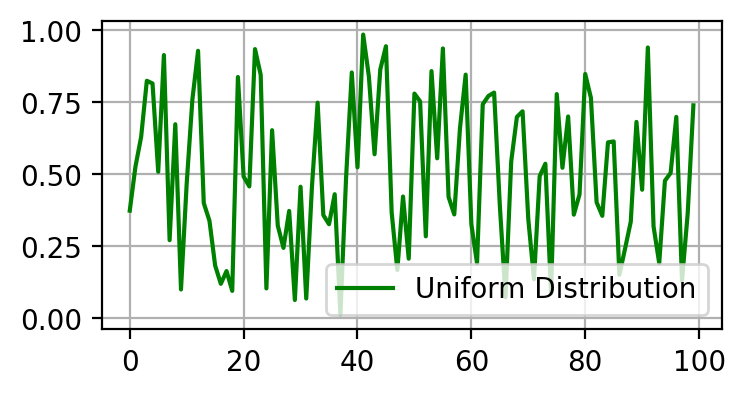

In [50]:
from matplotlib import pyplot as plt
# 得到100个元素的一维ndarray，每个数[0, 1)
x = np.random.rand(100)
print(type(x))
# np.arange(3) → 输出 array([0, 1, 2]) -> 怎么连arange都忘了，干什么吃的
t = np.arange(len(x))
plt.figure(figsize=(4, 2), dpi=200)
plt.plot(t, x, 'g', label='Uniform Distribution')
plt.legend(loc='best')
plt.grid()
plt.show()